# 03 · Model bake-off, calibration & P&L (Session 3)

This notebook **summarizes** Session 3. The heavy computation lives in two
reproducible scripts (tuning three models with time-aware CV takes ~70 min):
- `src/bakeoff.py` — 3A model bake-off + 3C with/without LC-grade comparison
- `src/calibrate_and_pnl.py` — 3B calibration + 3D realized-cashflow P&L

Here we load the saved results and walk through the story. Everything is
evaluated **out-of-time on 2016** (train ≤2015), directly comparable to the
Session-2 logistic baseline (**AUC 0.709**).


In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REP = ROOT / "reports"
params = json.loads((REP / "bakeoff_best_params.json").read_text())

## 3A — The bake-off: RandomForest vs XGBoost vs LightGBM

Each model tuned with `RandomizedSearchCV` over a `TimeSeriesSplit(3)` (folds
respect time). **Model selection is by cross-validated AUC**; test metrics are
the unbiased final report.

In [2]:
res = pd.read_csv(REP / "bakeoff_results.csv")
res

,model,cv_auc,test_auc,test_gini,test_ks,fit_seconds
0,XGBoost,0.7286,0.7199,0.4398,0.3163,608
1,LightGBM,0.7286,0.7182,0.4364,0.3138,989
2,RandomForest,0.7226,0.7076,0.4152,0.2981,2606


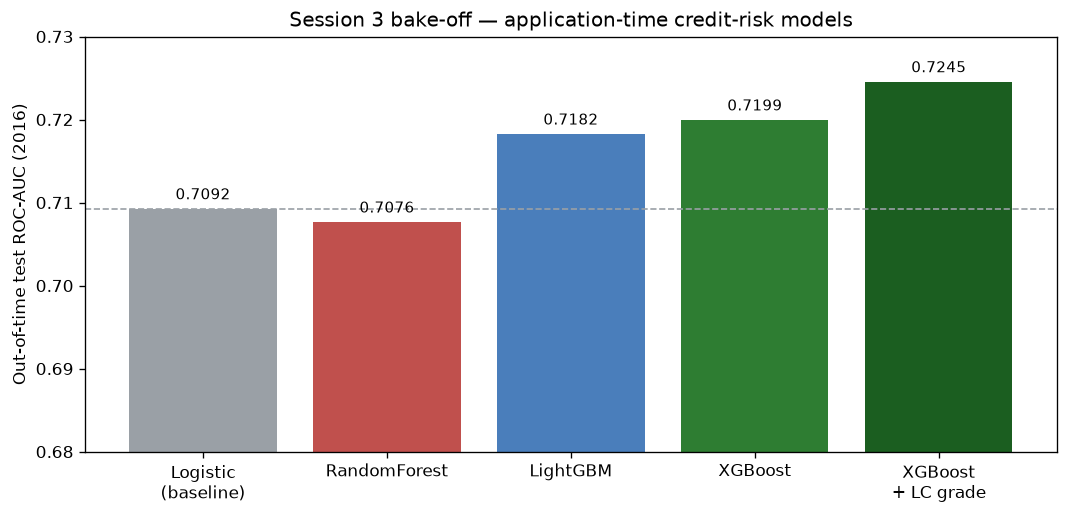

In [3]:
Image(filename=str(REP / "bakeoff_comparison.png"))

**Findings**

- **Gradient boosting wins, but modestly:** XGBoost 0.720 vs logistic 0.709
  (+0.011 AUC). Credit-default signal is largely *monotonic*, which a
  well-specified logistic already captures — boosting adds real but incremental
  value from interactions/non-linear thresholds. A giant jump here would be a
  leakage red flag.
- **RandomForest (0.708) lost to the logistic baseline** despite ~43 min of
  compute — a clean reminder that complexity ≠ accuracy. (It also ran with
  median imputation, while the boosters used native NaN handling.)
- **XGBoost ≈ LightGBM** (tied on CV AUC) — expected, both are histogram
  gradient boosters. XGBoost edged the test set, so it's the winner.

Winning XGBoost hyperparameters — moderate depth, well-regularized, consistent
with a not-wildly-non-linear problem:

In [4]:
params["best_params"]["XGBoost"]

{'subsample': 0.7,
 'reg_lambda': 5.0,
 'n_estimators': 600,
 'min_child_weight': 5,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

## 3C — How much is LendingClub's own grade worth?

Refit the winner with vs. without LC's `grade`/`sub_grade`/`int_rate`.

In [5]:
pd.DataFrame([params["comparison_3c"]])

,winner,app_only_test_auc,app_plus_lc_test_auc,auc_lift_from_lc
0,XGBoost,0.7199,0.7245,0.0046


**+0.0046 AUC.** Our application-time features already recover essentially
*all* of the ranking power in LC's proprietary grade — it adds under half a
point of AUC on top. Strong portfolio line: the model reproduces LC's own risk
assessment from raw application data.

## 3B — Calibration (the P&L needs real probabilities)

Time-based calibration fold: fit on ≤2014, calibrate (isotonic) on 2015, test
on 2016.

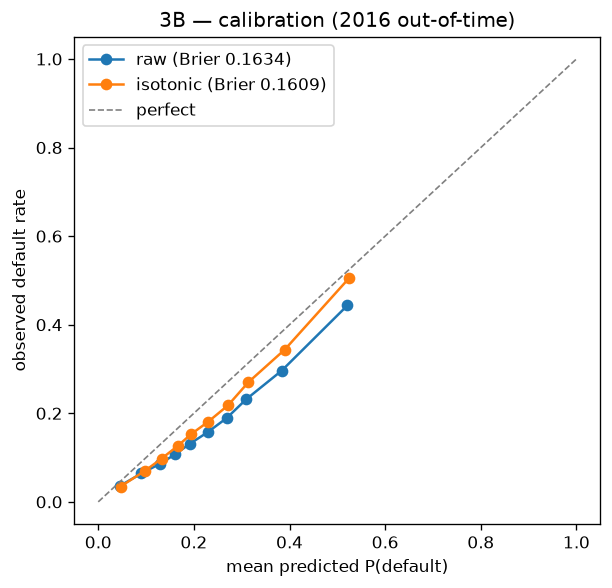

In [6]:
Image(filename=str(REP / "calibration_curve.png"))

Both curves sit **below the diagonal**: the model **under-predicts** default
risk on 2016 (observed rate > predicted at every level). That's **concept drift
made visible** — trained on ≤2014 (~15–18% default), applied to 2016 (23%
realized, inflated by censoring). Isotonic nudges predictions toward reality
(Brier 0.1634 → 0.1609) but can't fully close the gap, because 2015 drifted
less than 2016. In production you'd recalibrate on the most recent data
continuously.

## 3D — Realized-cashflow P&L backtest on 2016

No formula assumptions: each loan's actual net dollars =
`total_pymnt + recoveries − funded_amnt`. (Those are leakage as *features* —
used here only to score the policy's realized outcome, which the model never
saw.) Empirical **LGD on 2016 defaults ≈ 63%** of funded principal.

In [7]:
sweep = pd.read_csv(REP / "pnl_sweep.csv")
approve_all = sweep.iloc[sweep['approve_rate'].idxmax()]   # ~approve everyone
best = sweep.loc[sweep['total_profit'].idxmax()]
summary = pd.DataFrame({
    'policy': ['approve all (current book)', f"profit-max: PD <= {best.threshold:.3f}"],
    'approve_rate': [approve_all.approve_rate, best.approve_rate],
    'book_default_rate': [approve_all.book_default_rate, best.book_default_rate],
    'total_profit_$M': [approve_all.total_profit/1e6, best.total_profit/1e6],
})
summary.round(3)

,policy,approve_rate,book_default_rate,total_profit_$M
0,approve all (current book),1.000,0.233,10.897
1,profit-max: PD <= 0.232,0.692,0.158,109.378


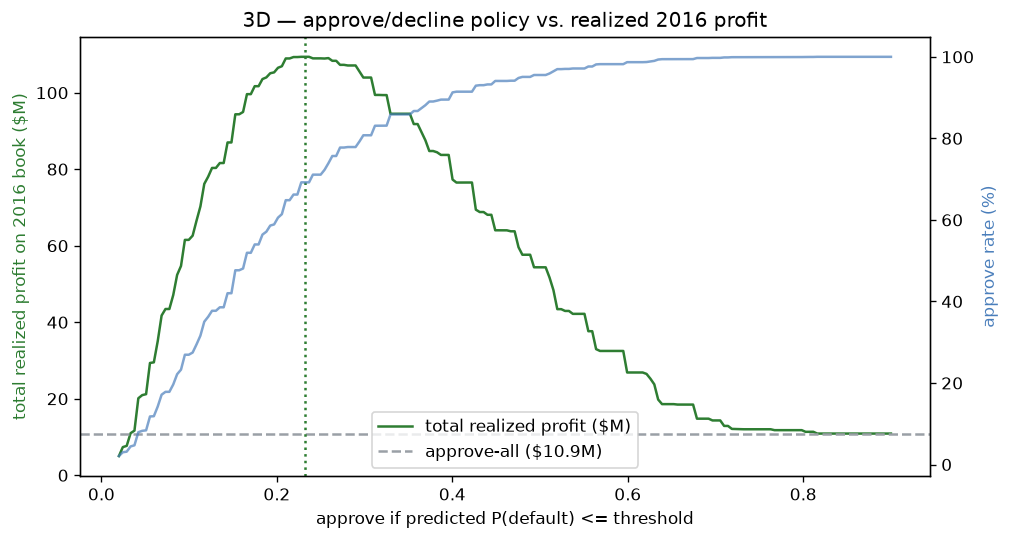

In [8]:
Image(filename=str(REP / "pnl_threshold.png"))

The classic **inverted-U**: decline too little and you keep the defaulters;
decline too much and you forgo good-loan interest. The profit-maximizing cutoff
(**PD ≤ ~0.23**) declines the riskiest ~31%, cuts the book default rate from
23% to ~16%, and lifts realized profit from ~\$11M to ~\$109M.

### Honest caveats (as important as the headline)
1. **The absolute \$ uplift is inflated by 2016 censoring** — that 23% realized
   default rate over-represents fast-defaulters (survivorship bias). The *shape*
   (risk-based cutoffs raise profit) is robust; the exact dollar figure is
   optimistic. A fully-matured book would show a smaller lift.
2. **Undiscounted** — ignores time-value; good-loan interest accrues over years,
   default losses are near-immediate.
3. **Declining 31% is commercially aggressive** — a real lender balances profit
   against growth; `reports/pnl_sweep.csv` has the full curve to pick any point.
4. **Under-calibration** means the stated PDs understate true 2016 risk, so the
   cutoff sits on slightly optimistic probabilities.

## Sensitivity checks

### 1 — stricter maturity cutoff (drop 2016+)

We flagged that the 2016 test book is right-censored, inflating its default rate
and the P&L uplift. To test it, we re-ran the pipeline with a **Dec-2015 cutoff**
(train ≤2014 / test 2015, ~10% censored vs 31%), **reusing the tuned
hyperparameters** so only the cutoff changes. (`src/sensitivity_cutoff.py`.)

In [9]:
import json
sens = json.loads((REP / "sensitivity_cutoff.json").read_text())
o, s = sens["original_2016"], sens["strict_2015"]
pd.DataFrame({
    "metric": ["XGBoost AUC", "LC-grade lift", "empirical LGD",
               "approve-all profit $M", "profit-max PD cutoff", "approve rate",
               "profit uplift $M"],
    "Dec-2016 (orig)": [o["xgb"], o["lc_lift"], o["lgd"], o["approve_all_M"],
                        o["pm_threshold"], o["pm_approve"],
                        o["pm_profit_M"] - o["approve_all_M"]],
    "Dec-2015 (strict)": [s["xgb"], s["lc_lift"], s["lgd"], s["approve_all_M"],
                          s["pm_threshold"], s["pm_approve"],
                          s["pm_profit_M"] - s["approve_all_M"]],
}).round(4)

,metric,Dec-2016 (orig),Dec-2015 (strict)
0,XGBoost AUC,0.7199,0.7371
1,LC-grade lift,0.0046,0.0057
2,empirical LGD,0.6330,0.5834
3,approve-all profit $M,10.9000,304.0139
4,profit-max PD cutoff,0.2320,0.3605
5,approve rate,0.6920,0.9002
6,profit uplift $M,98.5000,35.0270


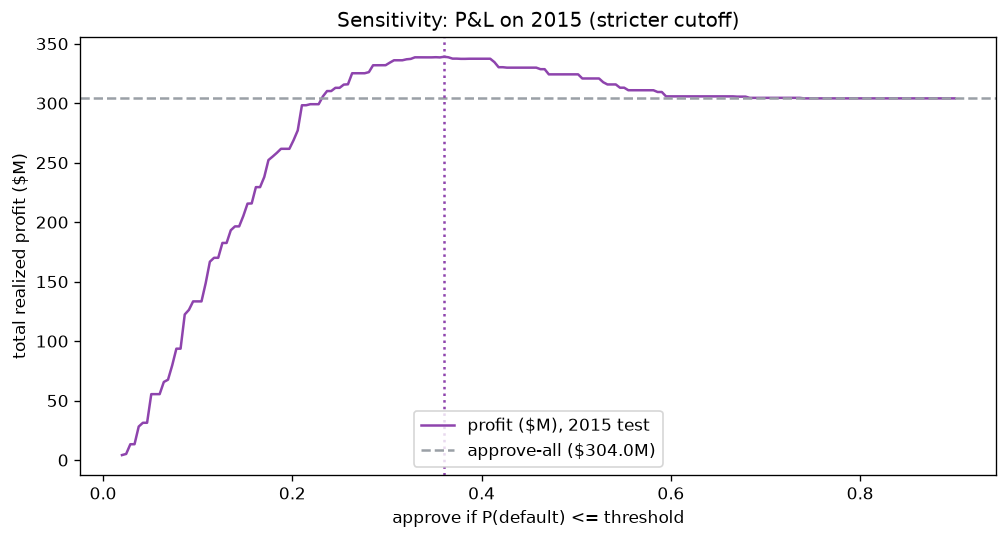

In [10]:
Image(filename=str(REP / "sensitivity_pnl_2015.png"))

**Finding — the model conclusions hold, the P&L magnitude does not.**

- **Held:** XGBoost still wins, boosting still beats logistic, LC-grade still
  adds ~nothing (+0.006). So we **keep the XGBoost model** — it's robust to the
  cutoff. (AUCs are even a touch higher on 2015, since 2016 was a harder test:
  further from training *and* more censored.)
- **Changed (as predicted):** the 2016 book only looked barely-profitable
  (\$11M) because censoring inflated its default rate, which made aggressive
  declining look heroic (+\$98M, decline 31%). On the cleaner 2015 book the
  book is **genuinely profitable (\$304M)**, risk-based cutoffs still help but
  far less — **+\$35M at a ~10% decline rate** — and the profit curve is much
  flatter. The *direction* was right; the *dollar magnitude and optimal
  operating point* on 2016 were a censoring artifact. Caveat confirmed.


### 2 — L1 / elastic-net logistic (feature selection)

Follows up the redundancy discussion: does a *sparse* logistic match the full L2
model, and how many features does it need? Same Dec-2016 setup as the baseline.
(`src/sensitivity_penalty.py`.)

In [11]:
pen = pd.DataFrame(json.loads((REP / "sensitivity_penalty.json").read_text()))
pen[["model", "test_auc", "test_ks", "n_nonzero", "n_features"]]

,model,test_auc,test_ks,n_nonzero,n_features
0,L2 (ridge),0.7087,0.3005,156,156
1,L1 (lasso),0.7087,0.3005,154,156
2,elastic-net,0.7087,0.3005,156,156


**Finding.** All three penalties land on the *same* AUC (~0.709), and L1
zeroes out only **2 of 156** features at standard strength. Two takeaways:
the regularizer choice is irrelevant to performance here (the L2 baseline lost
nothing), and there's no cheap redundancy for L1 to prune — the model draws on
broad signal, consistent with the SHAP importance being spread across many
features rather than a dominant few.

## Session 3 recap

| | AUC | Gini | KS |
|---|---|---|---|
| Logistic (Session 2) | 0.709 | 0.419 | 0.301 |
| **XGBoost (winner)** | **0.720** | **0.440** | **0.316** |

Plus: LC-grade worth only +0.005 AUC; a calibrated PD (with visible residual
drift); and a P&L backtest showing risk-based cutoffs materially improve
realized profit.

**Next — Session 4:** SHAP interpretability on the XGBoost winner. **Session 5:**
Streamlit app + written recommendation.